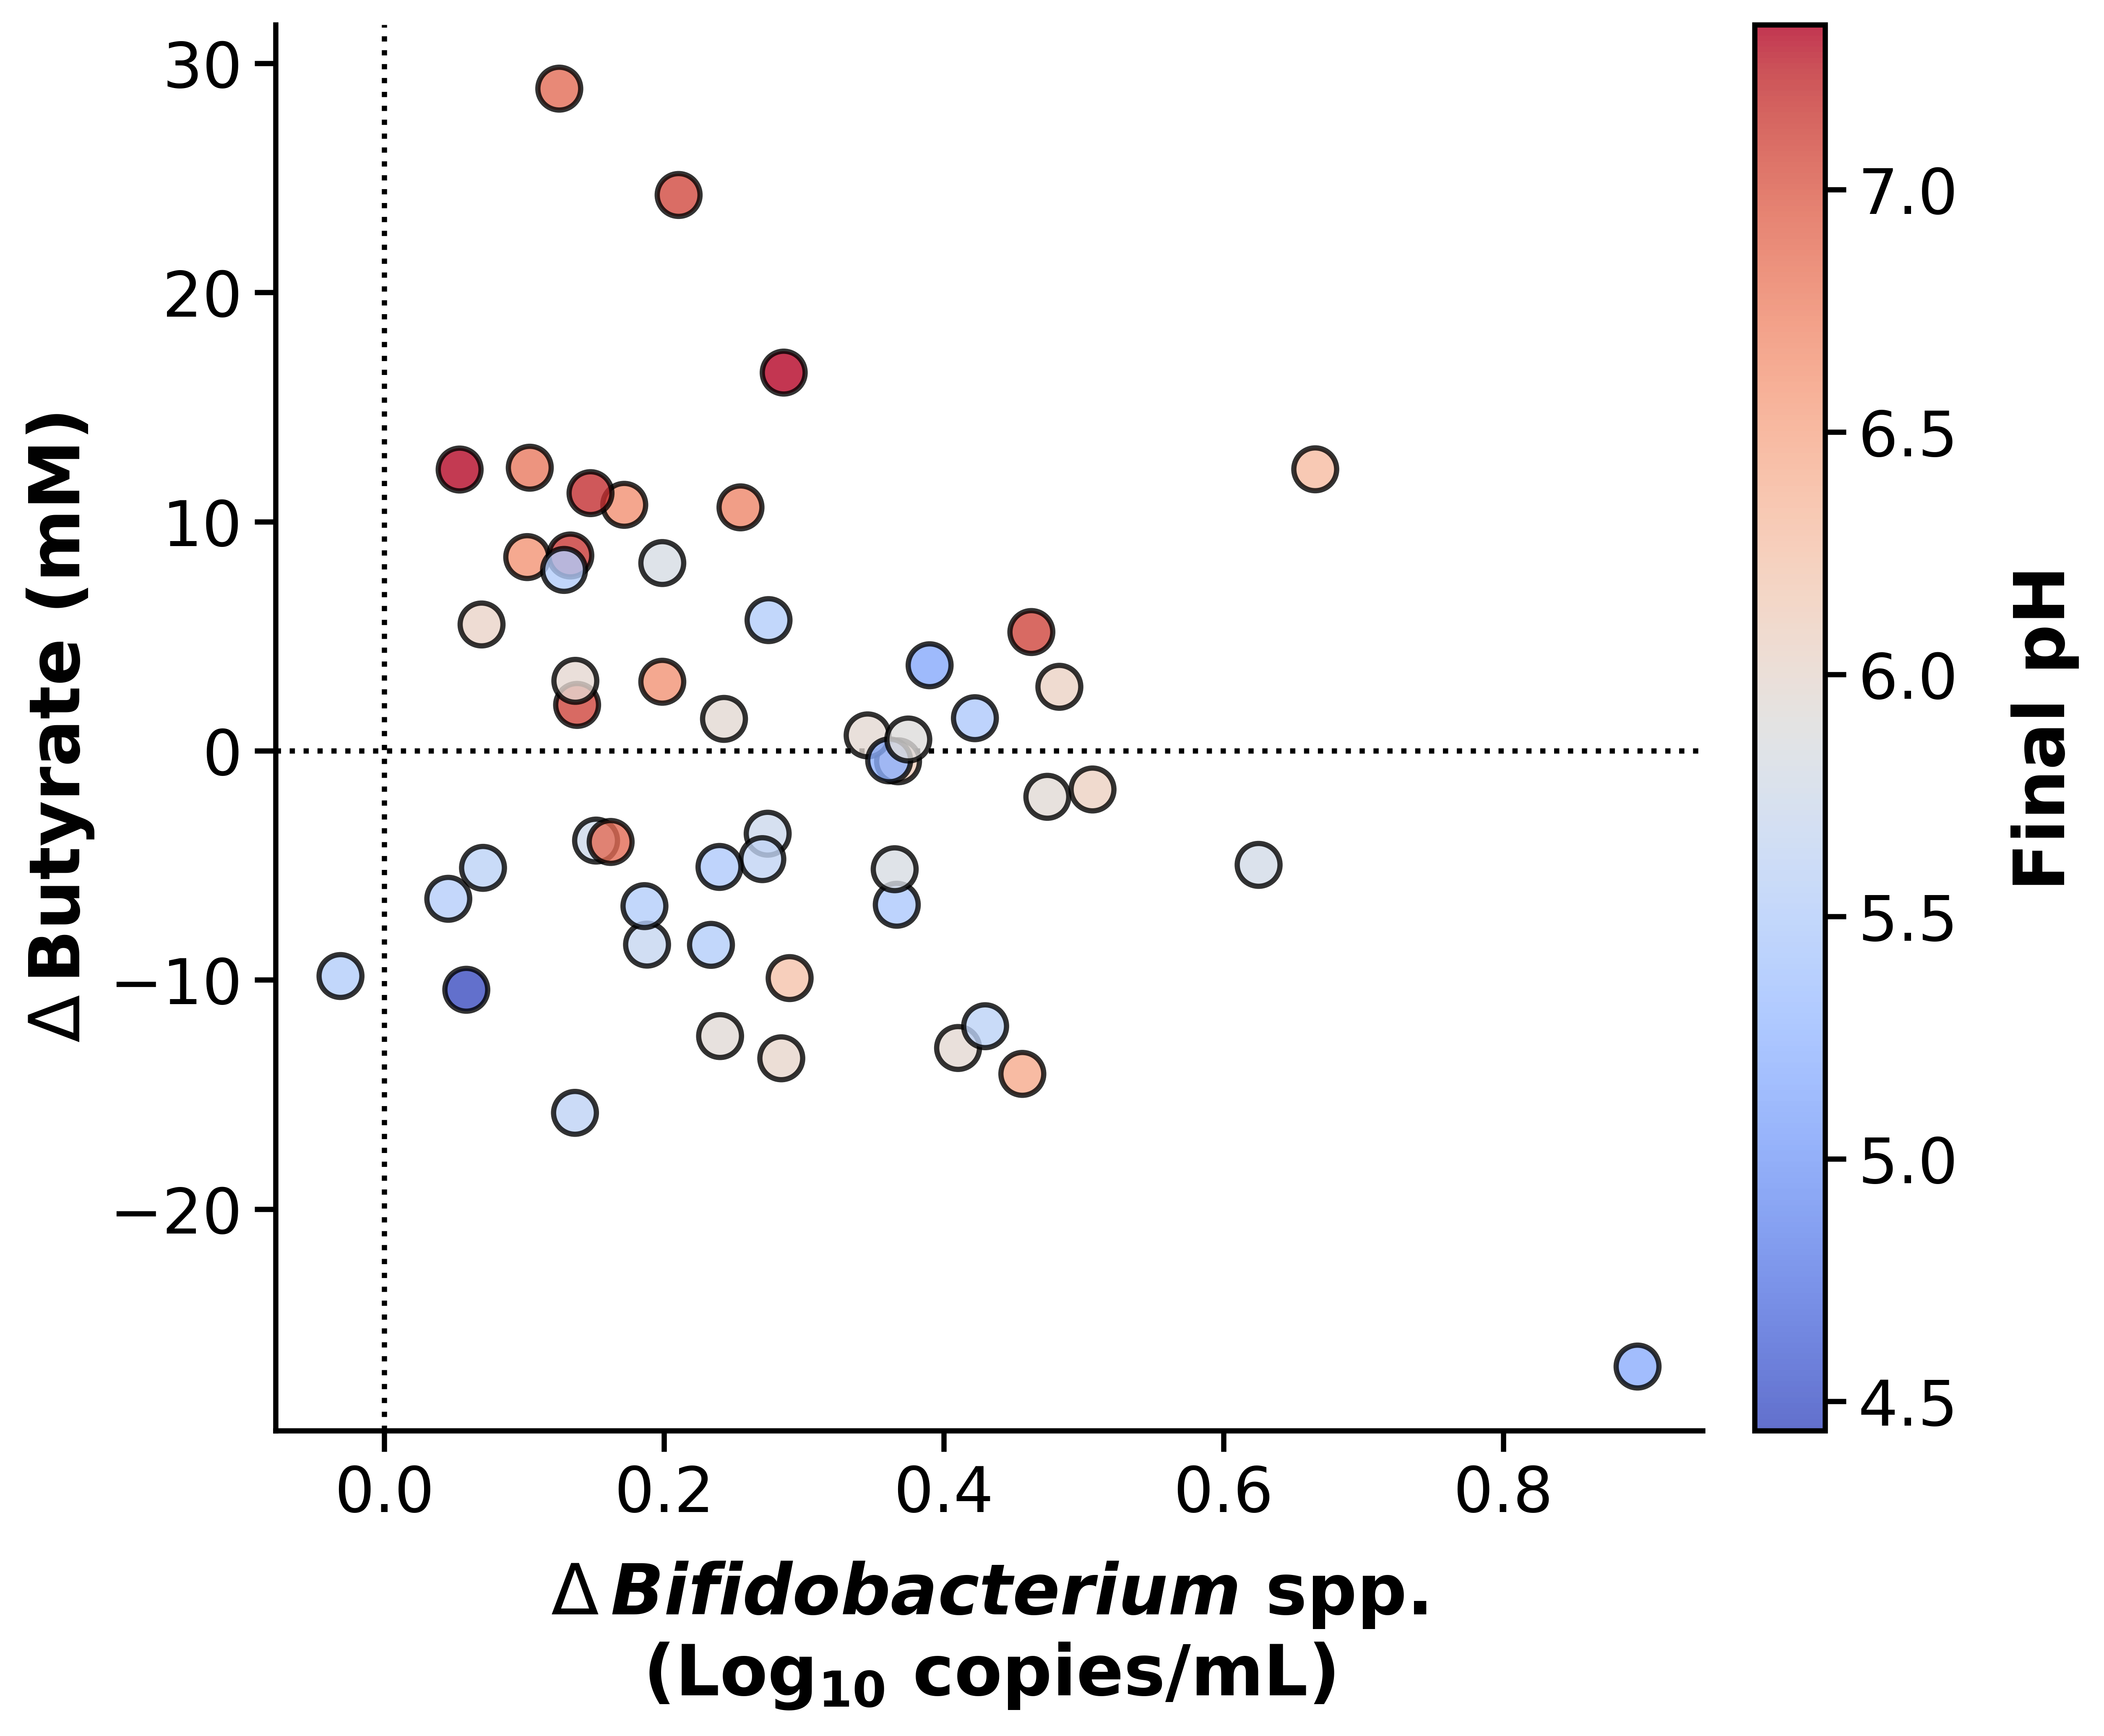

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Arial:italic:bold'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

DPI_SETTING = 600

df_ph = pd.read_csv('pH.csv')
df_buty = pd.read_csv('Butyrate(mM).csv')
df_bifi = pd.read_csv('Bifidobacterium(qPCR).csv')

donors = [c for c in df_ph.columns if c.startswith('HS-')]

def get_data(df, name):
    mask = df['KULFFI'].str.strip() == name
    if not mask.any(): return pd.Series(index=donors, dtype=float)
    s = df[mask][donors].iloc[0]
    s = s.astype(str).str.replace(' ', '')
    s = s.str.replace(r'\.E\+', 'E+', regex=True)
    s = s.str.replace(r'\.E\-', 'E-', regex=True)
    s = s.replace(['Undetermined', '-', 'nan', '#VALUE!', ''], np.nan)
    return pd.to_numeric(s, errors='coerce')

inulin_ph_final = get_data(df_ph, 'Inulin')
ctrl_buty = get_data(df_buty, 'Control')
inulin_buty = get_data(df_buty, 'Inulin')
delta_buty = inulin_buty - ctrl_buty

ctrl_bifi = get_data(df_bifi, 'Control')
inulin_bifi = get_data(df_bifi, 'Inulin')
delta_bifi = np.log10(inulin_bifi.replace(0, np.nan)) - np.log10(ctrl_bifi.replace(0, np.nan))

df_plot = pd.DataFrame({
    'Donor': donors,
    'Delta_Bifi': delta_bifi.values,
    'Delta_Butyrate': delta_buty.values,
    'Final_pH': inulin_ph_final.values
}).dropna()

fig, ax = plt.subplots(figsize=(8.5, 7), dpi=DPI_SETTING)

scatter = ax.scatter(
    x=df_plot['Delta_Bifi'],
    y=df_plot['Delta_Butyrate'],
    c=df_plot['Final_pH'],
    cmap='coolwarm',
    s=150,
    edgecolor='black',
    linewidth=1.5,
    alpha=0.8,
    zorder=3
)

ax.axhline(0, color='black', linestyle=':', linewidth=1.5, zorder=1)
ax.axvline(0, color='black', linestyle=':', linewidth=1.5, zorder=1)

cbar = plt.colorbar(scatter, ax=ax, pad=0.03)
cbar.set_label('Final pH', fontsize=20, fontweight='bold', labelpad=15)
cbar.ax.tick_params(labelsize=18, width=1.5, length=6)
cbar.outline.set_linewidth(1.5)

ax.set_xlabel(r'$\Delta\,$$\mathit{Bifidobacterium}$ spp.' + '\n' + r'(Log$_{\mathbf{10}}$ copies/mL)', fontsize=20, fontweight='bold', labelpad=10)
ax.set_ylabel(r'$\Delta\,$Butyrate (mM)', fontsize=20, fontweight='bold')

sns.despine(ax=ax, trim=False)

for spine in ax.spines.values():
    if spine.get_visible():
        spine.set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=18, width=1.5, length=6)

plt.tight_layout()

output_file = 'Figure_6b.pdf'
plt.savefig(output_file, dpi=DPI_SETTING, bbox_inches='tight')